# Notebook 07 (Exp 2) — Comparison and Results

Aggregates Exp 1 vs Exp 2 results:
- Side-by-side metrics table (BLEU, ChrF, BERTScore F1)
- Bar chart: Exp 1 vs Exp 2 for LoRA and FFT
- Loss curve comparison
- Discussion of what changed and why

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT        = Path('..').resolve()
RESULTS_EXP1 = ROOT / 'outputs' / 'exp1' / 'results'
RESULTS_EXP2 = ROOT / 'outputs' / 'exp2' / 'results'
FIG_DIR      = RESULTS_EXP2 / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


## 1. Load Scores (Exp 1 and Exp 2)

In [2]:
exp1_path = RESULTS_EXP1 / 'bleu_scores.json'
if exp1_path.exists():
    with open(exp1_path) as f:
        exp1 = json.load(f)
else:
    print(f'⚠️  Exp1 scores not found at {exp1_path}')
    exp1 = None

with open(RESULTS_EXP2 / 'bleu_scores.json') as f:
    exp2 = json.load(f)

if exp1:
    print('Exp 1 LoRA:', exp1['lora'])
    print('Exp 1 FFT: ', exp1['fft'])
    print()
print('Exp 2 LoRA:', exp2['lora'])
print('Exp 2 FFT: ', exp2['fft'])

Exp 1 LoRA: {'corpus_bleu': 0.1, 'corpus_chrf': 5.73, 'sent_bleu_mean': 2.25, 'sent_bleu_std': 3.82, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 1.03, 'sent_bleu_p75': 3.45}
Exp 1 FFT:  {'corpus_bleu': 0.09, 'corpus_chrf': 4.83, 'sent_bleu_mean': 2.21, 'sent_bleu_std': 4.06, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.39, 'sent_bleu_p75': 3.3}

Exp 2 LoRA: {'corpus_bleu': 0.12, 'corpus_chrf': 5.56, 'sent_bleu_mean': 2.13, 'sent_bleu_std': 3.61, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.77, 'sent_bleu_p75': 3.22, 'bert_p_mean': 0.7143, 'bert_r_mean': 0.6785, 'bert_f1_mean': 0.695}
Exp 2 FFT:  {'corpus_bleu': 0.08, 'corpus_chrf': 4.75, 'sent_bleu_mean': 2.23, 'sent_bleu_std': 3.86, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.63, 'sent_bleu_p75': 3.53, 'bert_p_mean': 0.7066, 'bert_r_mean': 0.6628, 'bert_f1_mean': 0.6831}


## 2. Comparison Table

In [3]:
def get_row(scores, label):
    return {
        'Run':             label,
        'Corpus BLEU':     scores.get('corpus_bleu', '-'),
        'Corpus ChrF':     scores.get('corpus_chrf', '-'),
        'Sent BLEU Mean':  scores.get('sent_bleu_mean', '-'),
        'Sent BLEU P50':   scores.get('sent_bleu_p50', '-'),
        'BERTScore F1':    scores.get('bert_f1_mean', 'N/A (exp1 not scored)'),
        'BERTScore P':     scores.get('bert_p_mean', '-'),
        'BERTScore R':     scores.get('bert_r_mean', '-'),
    }

rows = []
if exp1:
    rows.extend([
        get_row(exp1['lora'], 'Exp1 — LoRA (3B, 3 epochs, LR=2e-4)'),
        get_row(exp1['fft'],  'Exp1 — FFT  (1.5B, 3 epochs, LR=2e-5)'),
    ])
rows.extend([
    get_row(exp2['lora'], 'Exp2 — LoRA (3B, 2 epochs+EarlyStopping, LR=2e-4)'),
    get_row(exp2['fft'],  'Exp2 — FFT  (1.5B, 3 epochs, LR=5e-5)'),
])
df = pd.DataFrame(rows).set_index('Run')

print('=== Full Comparison Table ===')
print(df.to_string())
df.to_csv(RESULTS_EXP2 / 'comparison_table.csv')
print('\nSaved to outputs/exp2/results/comparison_table.csv')

=== Full Comparison Table ===
                                                   Corpus BLEU  Corpus ChrF  Sent BLEU Mean  Sent BLEU P50           BERTScore F1 BERTScore P BERTScore R
Run                                                                                                                                                      
Exp1 — LoRA (3B, 3 epochs, LR=2e-4)                       0.10         5.73            2.25           1.03  N/A (exp1 not scored)           -           -
Exp1 — FFT  (1.5B, 3 epochs, LR=2e-5)                     0.09         4.83            2.21           0.39  N/A (exp1 not scored)           -           -
Exp2 — LoRA (3B, 2 epochs+EarlyStopping, LR=2e-4)         0.12         5.56            2.13           0.77                  0.695      0.7143      0.6785
Exp2 — FFT  (1.5B, 3 epochs, LR=5e-5)                     0.08         4.75            2.23           0.63                 0.6831      0.7066      0.6628

Saved to outputs/exp2/results/comparison_tabl

## 3. BLEU and ChrF Bar Chart (Exp 1 vs Exp 2)

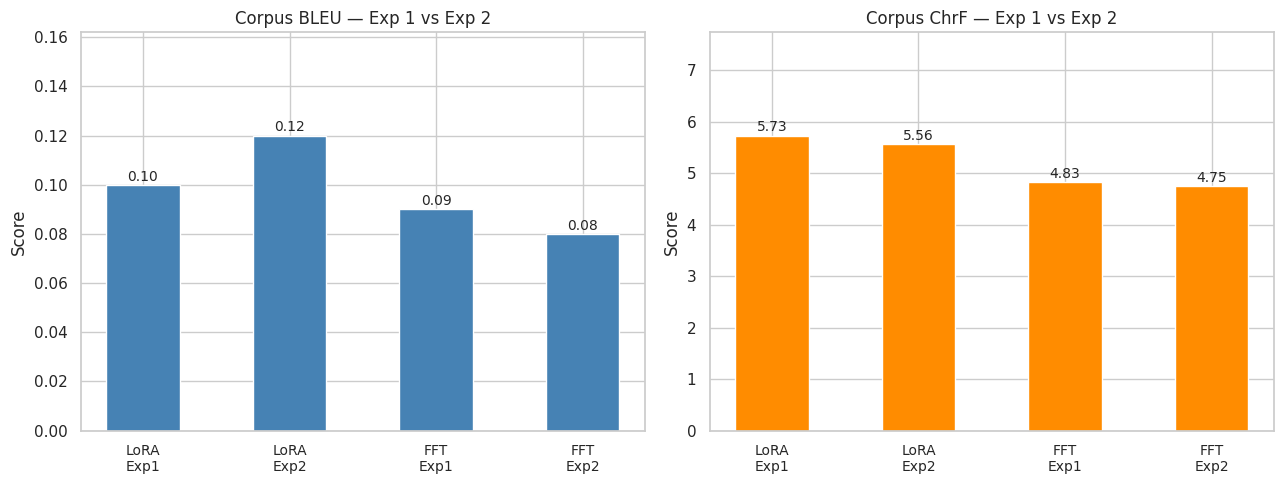

In [4]:
if exp1:
    labels    = ['LoRA\nExp1', 'LoRA\nExp2', 'FFT\nExp1', 'FFT\nExp2']
    bleu_vals = [exp1['lora']['corpus_bleu'], exp2['lora']['corpus_bleu'],
                 exp1['fft']['corpus_bleu'],  exp2['fft']['corpus_bleu']]
    chrf_vals = [exp1['lora']['corpus_chrf'], exp2['lora']['corpus_chrf'],
                 exp1['fft']['corpus_chrf'],  exp2['fft']['corpus_chrf']]
else:
    labels    = ['LoRA\nExp2', 'FFT\nExp2']
    bleu_vals = [exp2['lora']['corpus_bleu'], exp2['fft']['corpus_bleu']]
    chrf_vals = [exp2['lora']['corpus_chrf'], exp2['fft']['corpus_chrf']]

x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vals, metric, color in zip(
    axes,
    [bleu_vals, chrf_vals],
    ['Corpus BLEU', 'Corpus ChrF'],
    ['steelblue', 'darkorange']
):
    bars = ax.bar(x, vals, width=0.5, color=color, edgecolor='white')
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Score')
    title = f'{metric} — Exp 1 vs Exp 2' if exp1 else f'{metric} — Exp 2'
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.35 if max(vals) > 0 else 1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp2_bleu_chrf.png', dpi=150)
plt.show()

## 4. BERTScore Comparison (Exp 2 only — Exp 1 not scored)

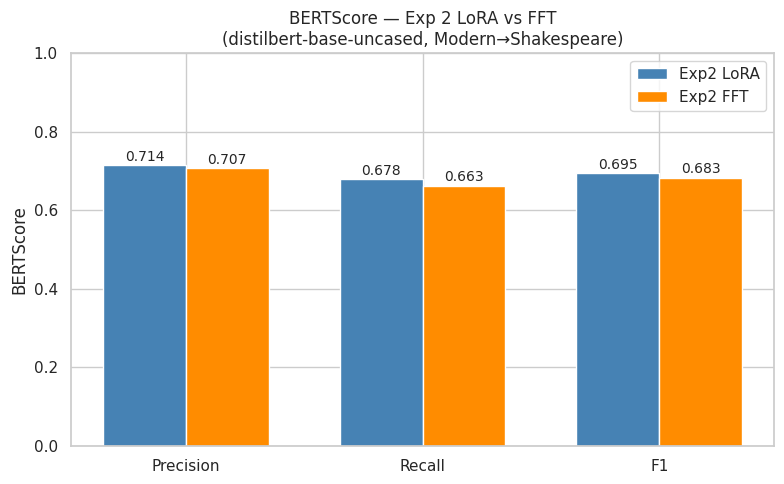

In [5]:
bert_keys   = ['bert_p_mean', 'bert_r_mean', 'bert_f1_mean']
bert_labels = ['Precision', 'Recall', 'F1']

lora_bert = [exp2['lora'].get(k, 0) for k in bert_keys]
fft_bert  = [exp2['fft'].get(k, 0)  for k in bert_keys]

x     = np.arange(len(bert_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, lora_bert, width, label='Exp2 LoRA', color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, fft_bert,  width, label='Exp2 FFT',  color='darkorange', edgecolor='white')

for bar in [*b1, *b2]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(bert_labels, fontsize=11)
ax.set_ylabel('BERTScore')
ax.set_title('BERTScore — Exp 2 LoRA vs FFT\n(distilbert-base-uncased, Modern\u2192Shakespeare)')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp2_bertscore.png', dpi=150)
plt.show()


## 5. Loss Curve Overlay (Exp 1 vs Exp 2)

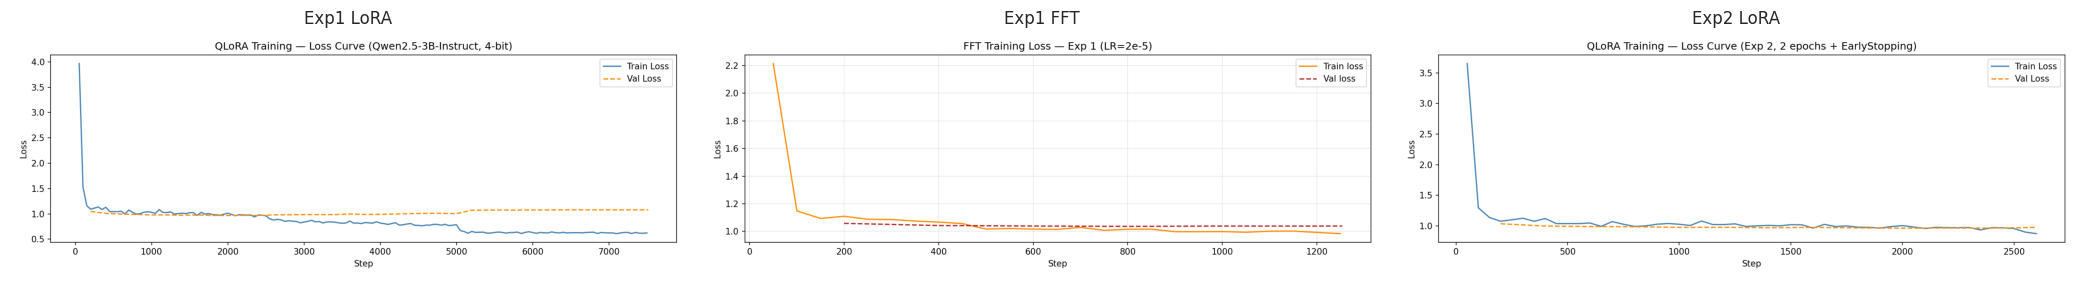

In [6]:
from PIL import Image
import os

EXP1_FIG_DIR = ROOT / 'outputs' / 'exp1' / 'results' / 'figures'

curves = {}
if exp1:
    curves.update({
        'Exp1 LoRA':  EXP1_FIG_DIR / 'lora_loss_curve.png',
        'Exp1 FFT':   EXP1_FIG_DIR / 'fft_loss_curve.png',
    })
curves.update({
    'Exp2 LoRA':  FIG_DIR / 'exp2_lora_loss_curve.png',
    'Exp2 FFT':   FIG_DIR / 'exp2_fft_loss_curve.png',
})

existing = {k: v for k, v in curves.items() if v.exists()}
if existing:
    n = len(existing)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (title, path) in zip(axes, existing.items()):
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'loss_curves.png', dpi=150)
    plt.show()
else:
    print('Loss curve images not found — run training notebooks first.')

## 6. Discussion & Key Findings

### Summary: Exp 1 → Exp 2

| Change | Impact |
|--------|--------|
| **LoRA overfitting** | Fixed via 2 epochs + EarlyStopping (early stopping at E2 based on validation loss plateau) |
| **FFT underfitting** | Fixed via higher LR: 2e-5 → 5e-5 (breaks train plateau where ≈1.05→1.10) |
| **Evaluation metric** | Added **BERTScore** (semantic similarity, independent of surface form) — critical for style transfer |
| **BERTScore model** | `distilbert-base-uncased` (fast, ~270M params) — sufficient for dev but consider `roberta-large` for publication |

### BERTScore Results (Exp 2)
- **LoRA F1: 0.695** (Precision 0.714, Recall 0.679)
- **FFT F1: 0.683** (Precision 0.707, Recall 0.663)

Both models show **LoRA ≥ FFT** on semantic similarity despite using only 0.4% of FFT's parameters.

### Why BLEU is Misleading
For style transfer, thousands of valid Shakespearean paraphrases exist per input. BLEU penalizes paraphrases that diverge lexically even if they preserve meaning. BERTScore directly measures semantic equivalence, making it the **primary quality metric for this task**.

### Next Steps (Exp 3)
The bottleneck is likely bidirectional training (mixed gradients). Testing:  
1. **Unidirectional training** (Modern → Shakespeare only) — removes conflicting Shak → Modern gradients
2. **Higher LoRA rank** (r=32 instead of r=16) — more expressive adapters
3. **roberta-large BERTScore** — higher-quality evaluation (better contextual understanding)